# 03. Global ML Models (Codex edition)

This notebook moves from the four-series classical case study to a **global panel ML setup**. The idea is simple:

- train one model across all eligible series
- use raw feature columns plus lagged target history
- compare a simple lag-1 baseline against **LightGBM** and **XGBoost**

This is the notebook that asks the practical modeling question:

**Do global ML models beat a simple naive baseline on the cutoff-based validation split that matches the project setup?**

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from IPython.display import display
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 115
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data/ts-forecasting"
PROCESSED_DIR = PROJECT_ROOT / "data/processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

VAL_CUTOFF = 2880
SEED = 42
LAGS = [1, 3, 5, 10]
ROLL_WINDOWS = [5, 20]
CASE_TAIL = 80

series_keys = ["code", "sub_code", "sub_category", "horizon"]
PRED_MAP = {
    "Naive": "naive_pred",
    "LightGBM": "lgb_pred",
    "XGBoost": "xgb_pred",
}
MODEL_SLUG = {
    "Naive": "naive",
    "LightGBM": "lightgbm",
    "XGBoost": "xgboost",
}
MODEL_COLOR = {
    "Naive": "#808080",
    "LightGBM": "#4C72B0",
    "XGBoost": "#DD8452",
}

train = pd.read_parquet(DATA_DIR / "train.parquet")
feature_cols = [c for c in train.columns if c.startswith("feature_")]


def weighted_skill(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred) & np.isfinite(weight)
    if not valid.any():
        return np.nan
    denom = np.sum(weight[valid] * (y_true[valid] ** 2))
    if denom == 0:
        return np.nan
    ratio = np.sum(weight[valid] * ((y_true[valid] - y_pred[valid]) ** 2)) / denom
    ratio = min(max(ratio, 0.0), 1.0)
    return float(np.sqrt(1.0 - ratio))


def weighted_rmse(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred) & np.isfinite(weight)
    if not valid.any():
        return np.nan
    return float(
        np.sqrt(
            np.sum(weight[valid] * ((y_true[valid] - y_pred[valid]) ** 2))
            / np.sum(weight[valid])
        )
    )


def weighted_mae(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred) & np.isfinite(weight)
    if not valid.any():
        return np.nan
    return float(
        np.sum(weight[valid] * np.abs(y_true[valid] - y_pred[valid]))
        / np.sum(weight[valid])
    )


def weighted_mase(y_true, y_pred, weight, scale):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    scale = np.asarray(scale, dtype=float)
    valid = (
        np.isfinite(y_true)
        & np.isfinite(y_pred)
        & np.isfinite(weight)
        & np.isfinite(scale)
        & (scale > 0)
    )
    if not valid.any():
        return np.nan
    scaled_abs_err = np.abs(y_true[valid] - y_pred[valid]) / scale[valid]
    return float(np.sum(weight[valid] * scaled_abs_err) / np.sum(weight[valid]))


def summarize_predictions(df, pred_map):
    rows = []
    for model, pred_col in pred_map.items():
        rows.append(
            {
                "model": model,
                "skill_score": weighted_skill(df["y_true"], df[pred_col], df["weight"]),
                "rmse": weighted_rmse(df["y_true"], df[pred_col], df["weight"]),
                "mae": weighted_mae(df["y_true"], df[pred_col], df["weight"]),
                "mase": weighted_mase(
                    df["y_true"], df[pred_col], df["weight"], df["mase_scale"]
                ),
            }
        )
    out = pd.DataFrame(rows)
    naive_rmse = out.loc[out["model"] == "Naive", "rmse"].iloc[0]
    naive_mae = out.loc[out["model"] == "Naive", "mae"].iloc[0]
    naive_mase = out.loc[out["model"] == "Naive", "mase"].iloc[0]
    out["rmse_vs_naive"] = out["rmse"] / naive_rmse
    out["mae_vs_naive"] = out["mae"] / naive_mae
    out["mase_vs_naive"] = out["mase"] / naive_mase
    return out.sort_values(["mase", "rmse"]).reset_index(drop=True)


def metric_bundle(df, pred_col):
    return {
        "skill": weighted_skill(df["y_true"], df[pred_col], df["weight"]),
        "rmse": weighted_rmse(df["y_true"], df[pred_col], df["weight"]),
        "mae": weighted_mae(df["y_true"], df[pred_col], df["weight"]),
        "mase": weighted_mase(df["y_true"], df[pred_col], df["weight"], df["mase_scale"]),
    }


def grouped_metric_table(df, group_col, pred_map):
    rows = []
    for key, grp in df.groupby(group_col, sort=True):
        row = {
            group_col: key,
            "rows": int(len(grp)),
            "total_weight": float(grp["weight"].sum()),
        }
        for model, pred_col in pred_map.items():
            slug = MODEL_SLUG[model]
            for metric_name, metric_value in metric_bundle(grp, pred_col).items():
                row[f"{slug}_{metric_name}"] = metric_value
        rows.append(row)
    return pd.DataFrame(rows).sort_values(group_col).reset_index(drop=True)


def feature_group_name(feature_name):
    if feature_name.startswith("feature_"):
        return "raw features"
    if feature_name.startswith("lag_"):
        return "lag features"
    if feature_name.startswith("roll_mean_"):
        return "rolling means"
    if feature_name.startswith("roll_std_"):
        return "rolling std"
    if feature_name == "expanding_mean":
        return "expanding mean"
    if feature_name in {"code_enc", "sub_code_enc", "sub_category_enc"}:
        return "panel identifiers"
    if feature_name == "series_step":
        return "series position"
    if feature_name in {"horizon", "ts_index"}:
        return "time index"
    return "other"


def get_series_frame(row):
    mask = np.logical_and.reduce(
        [
            train["code"] == row["code"],
            train["sub_code"] == row["sub_code"],
            train["sub_category"] == row["sub_category"],
            train["horizon"] == row["horizon"],
        ]
    )
    return train.loc[mask, ["ts_index", "y_target", "weight"]].sort_values("ts_index")


print(f"train shape: {train.shape}")
print(f"raw feature columns: {len(feature_cols)}")

/Users/jeetraj/Desktop/Everything/DAIICT/Sem_6/Applied_Forecasting_Methods/Project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train shape: (5337414, 94)
raw feature columns: 86


## 1. Eligible panel and representative series

We keep the same **cutoff-based validation split** used in the rest of the project:

- train rows: `ts_index <= 2880`
- validation rows: `ts_index > 2880`

A series is eligible only if it crosses that cutoff. We also recreate the same four representative series from `01_EDA.ipynb` so the ML notebook can end with directly comparable case studies.

,metric,value
0,eligible series,1930
1,eligible rows,316963
2,pre-cutoff rows,164257
3,post-cutoff validation rows,152706
4,raw feature columns,86


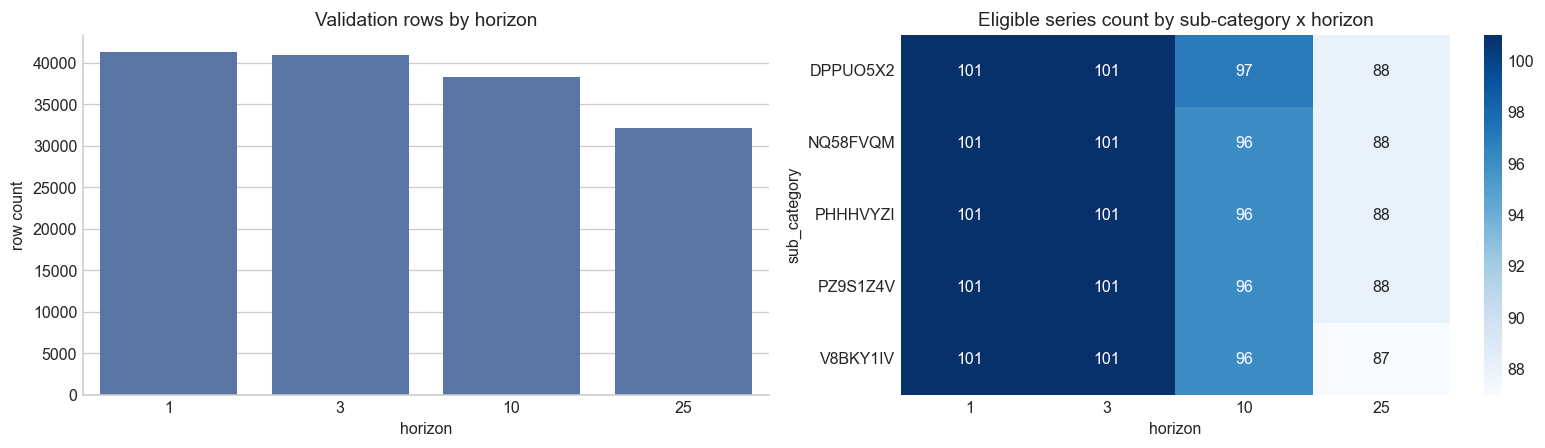

,reason,code,sub_code,sub_category,horizon,length,train_len_pre_cutoff,val_len_post_cutoff,total_weight,target_std
0,Longest History,X9BZ68VQ,OYJGNSQK,DPPUO5X2,1,212,55,157,9.060035e+02,2.641558
1,Highest Total Weight,SJZP0OVU,OYJGNSQK,NQ58FVQM,25,156,7,149,4.349747e+10,0.000394
2,Most Volatile,W4S29LF4,KL66VIS3,PHHHVYZI,25,162,131,31,4.562944e-01,296.760011
3,Most Stable,SJZP0OVU,OYJGNSQK,NQ58FVQM,1,170,7,163,3.869062e+10,0.000139


In [2]:
series_stats = (
    train.groupby(series_keys)
    .agg(
        start=("ts_index", "min"),
        end=("ts_index", "max"),
        length=("ts_index", "size"),
        total_weight=("weight", "sum"),
        target_std=("y_target", "std"),
    )
    .reset_index()
)
series_stats["crosses_cutoff"] = (
    (series_stats["start"] <= VAL_CUTOFF) & (series_stats["end"] > VAL_CUTOFF)
)
series_stats["train_len_pre_cutoff"] = series_stats["start"].rsub(VAL_CUTOFF).mul(0)
series_stats["val_len_post_cutoff"] = series_stats["end"].rsub(VAL_CUTOFF).mul(0)

coverage = (
    train.groupby(series_keys)["ts_index"]
    .agg(
        train_len_pre_cutoff=lambda s: int((s <= VAL_CUTOFF).sum()),
        val_len_post_cutoff=lambda s: int((s > VAL_CUTOFF).sum()),
    )
    .reset_index()
)
series_stats = series_stats.drop(columns=["train_len_pre_cutoff", "val_len_post_cutoff"]).merge(
    coverage, on=series_keys, how="left"
)

eligible_meta = series_stats[series_stats["crosses_cutoff"]].copy()
eligible = (
    train.merge(eligible_meta[series_keys], on=series_keys, how="inner")
    .sort_values(series_keys + ["ts_index"])
    .reset_index(drop=True)
)

support_summary = pd.DataFrame(
    [
        {"metric": "eligible series", "value": int(len(eligible_meta))},
        {"metric": "eligible rows", "value": int(len(eligible))},
        {
            "metric": "pre-cutoff rows",
            "value": int((eligible["ts_index"] <= VAL_CUTOFF).sum()),
        },
        {
            "metric": "post-cutoff validation rows",
            "value": int((eligible["ts_index"] > VAL_CUTOFF).sum()),
        },
        {"metric": "raw feature columns", "value": int(len(feature_cols))},
    ]
)
display(support_summary)

chosen_pool = eligible_meta[eligible_meta["length"] >= 120].copy()
stable_pool = chosen_pool[chosen_pool["target_std"].fillna(0) > 0]
chosen = (
    pd.concat(
        [
            chosen_pool.nlargest(1, "length").assign(reason="Longest History"),
            chosen_pool.nlargest(1, "total_weight").assign(reason="Highest Total Weight"),
            chosen_pool.nlargest(1, "target_std").assign(reason="Most Volatile"),
            stable_pool.nsmallest(1, "target_std").assign(reason="Most Stable"),
        ],
        ignore_index=True,
    )
    .drop_duplicates(subset=series_keys)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

horizon_rows = (
    eligible[eligible["ts_index"] > VAL_CUTOFF]
    .groupby("horizon")
    .size()
    .rename("validation_rows")
    .reset_index()
)
sns.barplot(data=horizon_rows, x="horizon", y="validation_rows", color="#4C72B0", ax=axes[0])
axes[0].set_title("Validation rows by horizon")
axes[0].set_xlabel("horizon")
axes[0].set_ylabel("row count")

support_heatmap = (
    eligible_meta.groupby(["sub_category", "horizon"]).size().unstack(fill_value=0).sort_index()
)
sns.heatmap(support_heatmap, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Eligible series count by sub-category x horizon")
axes[1].set_xlabel("horizon")
axes[1].set_ylabel("sub_category")

plt.tight_layout()
plt.show()

display(
    chosen[
        [
            "reason",
            "code",
            "sub_code",
            "sub_category",
            "horizon",
            "length",
            "train_len_pre_cutoff",
            "val_len_post_cutoff",
            "total_weight",
            "target_std",
        ]
    ]
)

The feature engineering here is strictly causal relative to the validation split:

- every lagged target feature uses **past realized values only**
- rolling and expanding features are built from **shifted** target history
- raw `feature_*` columns come directly from the dataset

So the global models can be aggressive without leaking future target information into the design matrix.

## 2. Feature engineering and matrix readiness

The ML models use four feature families:

- raw `feature_*` columns already present in the panel
- lagged targets and recent rolling summaries
- simple panel identifiers
- basic time-position fields (`horizon`, `ts_index`, `series_step`)

,feature_group,count,purpose
0,raw feature columns,86,exogenous information already provided by the ...
1,lag features,4,capture short-run target persistence
2,rolling mean / std,4,capture recent level and volatility
3,expanding mean,1,capture long-run series tendency
4,panel identifiers,3,let one global model behave differently across...
5,time-position fields,3,"retain horizon, global time, and within-series..."


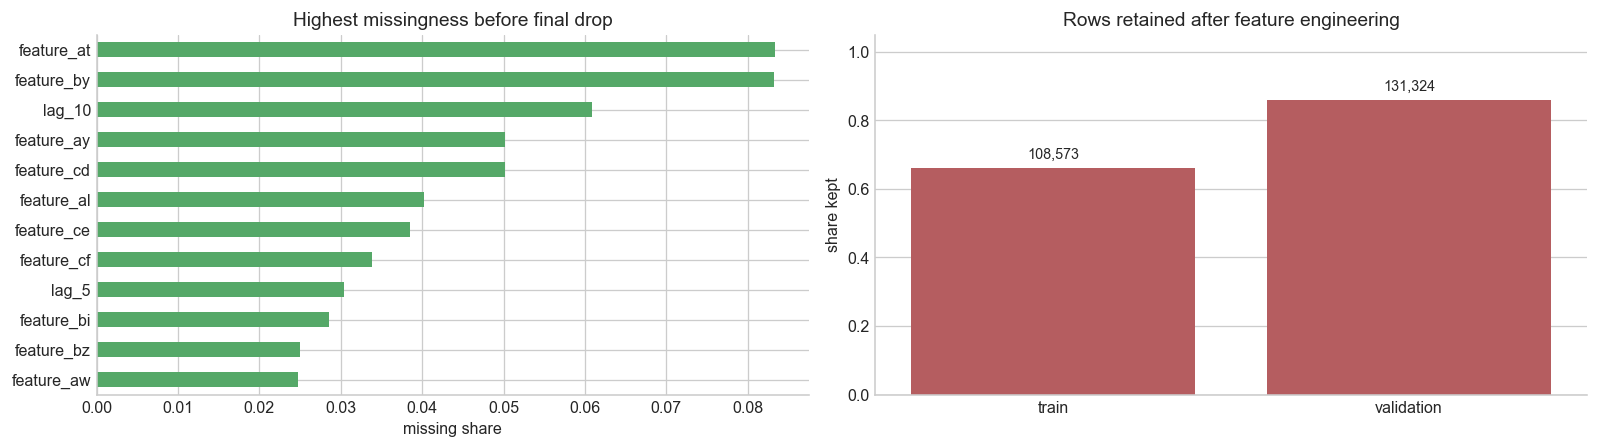

,split,rows_before_features,rows_after_features,kept_pct
0,train,164257,108573,0.660995
1,validation,152706,131324,0.859979


In [3]:
feature_group_table = pd.DataFrame(
    [
        {
            "feature_group": "raw feature columns",
            "count": len(feature_cols),
            "purpose": "exogenous information already provided by the dataset",
        },
        {
            "feature_group": "lag features",
            "count": len(LAGS),
            "purpose": "capture short-run target persistence",
        },
        {
            "feature_group": "rolling mean / std",
            "count": len(ROLL_WINDOWS) * 2,
            "purpose": "capture recent level and volatility",
        },
        {
            "feature_group": "expanding mean",
            "count": 1,
            "purpose": "capture long-run series tendency",
        },
        {
            "feature_group": "panel identifiers",
            "count": 3,
            "purpose": "let one global model behave differently across series",
        },
        {
            "feature_group": "time-position fields",
            "count": 3,
            "purpose": "retain horizon, global time, and within-series step",
        },
    ]
)
display(feature_group_table)

eligible["series_id"] = eligible[series_keys].astype(str).agg("__".join, axis=1)
eligible["series_step"] = eligible.groupby("series_id").cumcount()

for lag in LAGS:
    eligible[f"lag_{lag}"] = eligible.groupby("series_id")["y_target"].shift(lag)

shifted_target = eligible.groupby("series_id")["y_target"].shift(1)
for window in ROLL_WINDOWS:
    eligible[f"roll_mean_{window}"] = (
        shifted_target.groupby(eligible["series_id"])
        .rolling(window, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    eligible[f"roll_std_{window}"] = (
        shifted_target.groupby(eligible["series_id"])
        .rolling(window, min_periods=2)
        .std()
        .reset_index(level=0, drop=True)
        .fillna(0.0)
    )

eligible["expanding_mean"] = (
    shifted_target.groupby(eligible["series_id"])
    .expanding(min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

for col in ["code", "sub_code", "sub_category"]:
    eligible[f"{col}_enc"] = eligible[col].astype("category").cat.codes

mase_scale = (
    eligible.loc[eligible["ts_index"] <= VAL_CUTOFF]
    .groupby("series_id")["y_target"]
    .apply(
        lambda s: float(np.mean(np.abs(np.diff(s.to_numpy()))))
        if len(s) >= 2
        else np.nan
    )
    .rename("mase_scale")
)
eligible = eligible.merge(mase_scale, on="series_id", how="left")

engineered_cols = [
    *(f"lag_{lag}" for lag in LAGS),
    *(f"roll_mean_{window}" for window in ROLL_WINDOWS),
    *(f"roll_std_{window}" for window in ROLL_WINDOWS),
    "expanding_mean",
    "series_step",
    "code_enc",
    "sub_code_enc",
    "sub_category_enc",
]
model_features = feature_cols + engineered_cols + ["horizon", "ts_index"]

initial_train_rows = int((eligible["ts_index"] <= VAL_CUTOFF).sum())
initial_val_rows = int((eligible["ts_index"] > VAL_CUTOFF).sum())

ml_ready = eligible.dropna(subset=model_features).copy()

retention_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "rows_before_features": initial_train_rows,
            "rows_after_features": int((ml_ready["ts_index"] <= VAL_CUTOFF).sum()),
        },
        {
            "split": "validation",
            "rows_before_features": initial_val_rows,
            "rows_after_features": int((ml_ready["ts_index"] > VAL_CUTOFF).sum()),
        },
    ]
)
retention_summary["kept_pct"] = (
    retention_summary["rows_after_features"] / retention_summary["rows_before_features"]
)

missing_after_engineering = (
    eligible[model_features].isna().mean().sort_values(ascending=False).head(12)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
missing_after_engineering.sort_values().plot.barh(color="#55A868", ax=axes[0])
axes[0].set_title("Highest missingness before final drop")
axes[0].set_xlabel("missing share")
axes[0].set_ylabel("")

sns.barplot(data=retention_summary, x="split", y="kept_pct", color="#C44E52", ax=axes[1])
axes[1].set_title("Rows retained after feature engineering")
axes[1].set_xlabel("")
axes[1].set_ylabel("share kept")
axes[1].set_ylim(0, 1.05)
for bar, kept_rows in zip(axes[1].patches, retention_summary["rows_after_features"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{kept_rows:,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

display(retention_summary)

## 3. Train / validation matrices and model lineup

The baseline is intentionally simple:

- **Naive**: predict the previous observed target (`lag_1`)
- **LightGBM**: weighted gradient boosting trees
- **XGBoost**: weighted gradient boosting trees with a different implementation bias

This keeps the notebook focused on a fair question: does global tree boosting add value over a very simple one-step persistence baseline?

In [4]:
train_ml = ml_ready[ml_ready["ts_index"] <= VAL_CUTOFF].copy()
val_ml = ml_ready[ml_ready["ts_index"] > VAL_CUTOFF].copy()

X_train = train_ml[model_features]
y_train = train_ml["y_target"]
w_train = train_ml["weight"]

X_val = val_ml[model_features]
y_val = val_ml["y_target"]
w_val = val_ml["weight"]

matrix_summary = pd.DataFrame(
    [
        {"matrix": "X_train", "rows": X_train.shape[0], "cols": X_train.shape[1]},
        {"matrix": "X_val", "rows": X_val.shape[0], "cols": X_val.shape[1]},
    ]
)

lgb_params = dict(
    n_estimators=250,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1,
)

xgb_params = dict(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="mae",
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

display(matrix_summary)
display(
    pd.DataFrame(
        [
            {"model": "LightGBM", **lgb_params},
            {"model": "XGBoost", **xgb_params},
        ]
    )
)

,matrix,rows,cols
0,X_train,108573,101
1,X_val,131324,101


,model,n_estimators,learning_rate,num_leaves,subsample,colsample_bytree,random_state,n_jobs,verbosity,max_depth,objective,eval_metric,tree_method
0,LightGBM,250,0.05,63.0,0.8,0.8,42,-1,-1,NaN,NaN,NaN,NaN
1,XGBoost,250,0.05,NaN,0.8,0.8,42,-1,0,8.0,reg:squarederror,mae,hist


## 4. Train models and score the validation set

In [5]:
lgb_model = LGBMRegressor(**lgb_params)
lgb_model.fit(X_train, y_train, sample_weight=w_train)

xgb_model = XGBRegressor(**xgb_params)
xgb_model.fit(X_train, y_train, sample_weight=w_train)

val_preds = val_ml[
    [
        "id",
        "code",
        "sub_code",
        "sub_category",
        "horizon",
        "ts_index",
        "weight",
        "mase_scale",
        "lag_1",
        "y_target",
    ]
].copy()
val_preds = val_preds.rename(columns={"y_target": "y_true", "lag_1": "naive_pred"})
val_preds["lgb_pred"] = lgb_model.predict(X_val)
val_preds["xgb_pred"] = xgb_model.predict(X_val)
val_preds["series_key"] = val_preds[series_keys].astype(str).agg("__".join, axis=1)

overall_metrics = summarize_predictions(val_preds, PRED_MAP)
display(overall_metrics)

,model,skill_score,rmse,mae,mase,rmse_vs_naive,mae_vs_naive,mase_vs_naive
0,Naive,0.761104,0.001850,0.000311,2.430528,1.000000,1.000000,1.000000
1,LightGBM,0.000000,0.004215,0.000337,2.585195,2.278946,1.081702,1.063635
2,XGBoost,0.000000,0.403722,0.173120,2020.131145,218.286100,556.273010,831.148996


`skill_score` is still reported for compatibility with the project metric, but the notebook ranks models mainly with **RMSE, MAE, and MASE**. On this panel, the bounded skill score can be uninformative when the denominator is tiny.

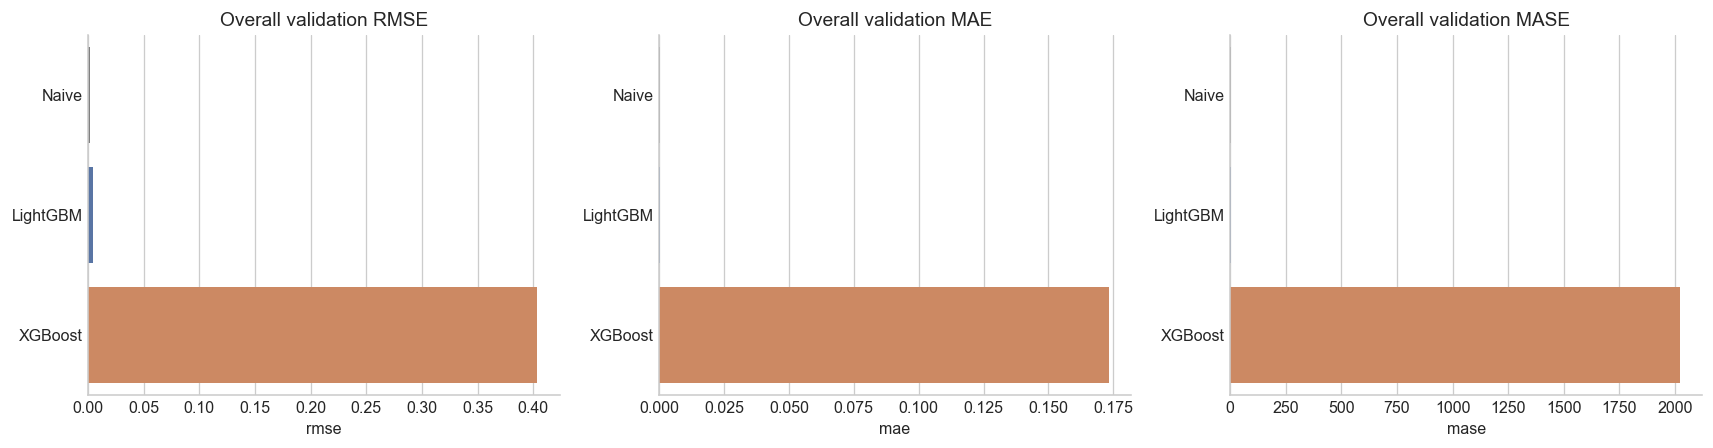

,model,skill_score
0,Naive,0.761104
1,LightGBM,0.000000
2,XGBoost,0.000000


In [6]:
plot_metrics = ["rmse", "mae", "mase"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, plot_metrics):
    order = overall_metrics.sort_values(metric)
    sns.barplot(
        data=order,
        x=metric,
        y="model",
        palette=[MODEL_COLOR[m] for m in order["model"]],
        ax=ax,
    )
    ax.set_title(f"Overall validation {metric.upper()}")
    ax.set_xlabel(metric)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

if np.nanmax(overall_metrics["skill_score"].fillna(0).to_numpy()) <= 1e-9:
    print("All overall skill scores clipped to zero; use RMSE / MAE / MASE for the ranking.")
else:
    display(overall_metrics[["model", "skill_score"]].sort_values("skill_score", ascending=False))

## 5. Performance by horizon and sub-category

The right question is not only “who wins overall?” but also “where do the gains come from?”

,horizon,rows,total_weight,naive_skill,naive_rmse,naive_mae,naive_mase,lightgbm_skill,lightgbm_rmse,lightgbm_mae,lightgbm_mase,xgboost_skill,xgboost_rmse,xgboost_mae,xgboost_mase
0,1,35577,6.665097e+11,0.000000,0.001628,0.000269,1.817598,0.000000,0.001251,0.000233,1.527020,0.0,0.362449,0.159629,1728.000299
1,3,35300,4.353098e+11,0.475373,0.001882,0.000317,1.544569,0.536201,0.001805,0.000349,1.673661,0.0,0.400609,0.174767,1515.432925
2,10,33107,3.155111e+11,0.827520,0.002067,0.000351,5.811792,0.000000,0.008757,0.000445,6.786994,0.0,0.436432,0.195179,4347.595196
3,25,27340,2.615633e+11,0.912274,0.002040,0.000361,1.388121,0.714841,0.003482,0.000451,1.730409,0.0,0.463233,0.178147,796.680117


,sub_category,rows,total_weight,naive_mase,lightgbm_mase,xgboost_mase
1,NQ58FVQM,26282,5.729242e+11,3.731602,4.113416,3262.719104
4,V8BKY1IV,25555,4.672392e+11,1.794720,1.744711,1077.752934
3,PZ9S1Z4V,26698,2.856092e+11,1.995942,2.066839,2084.484726
0,DPPUO5X2,26507,2.553217e+11,1.509408,1.649394,1277.890494
2,PHHHVYZI,26282,9.779964e+10,1.519227,1.603997,992.050701


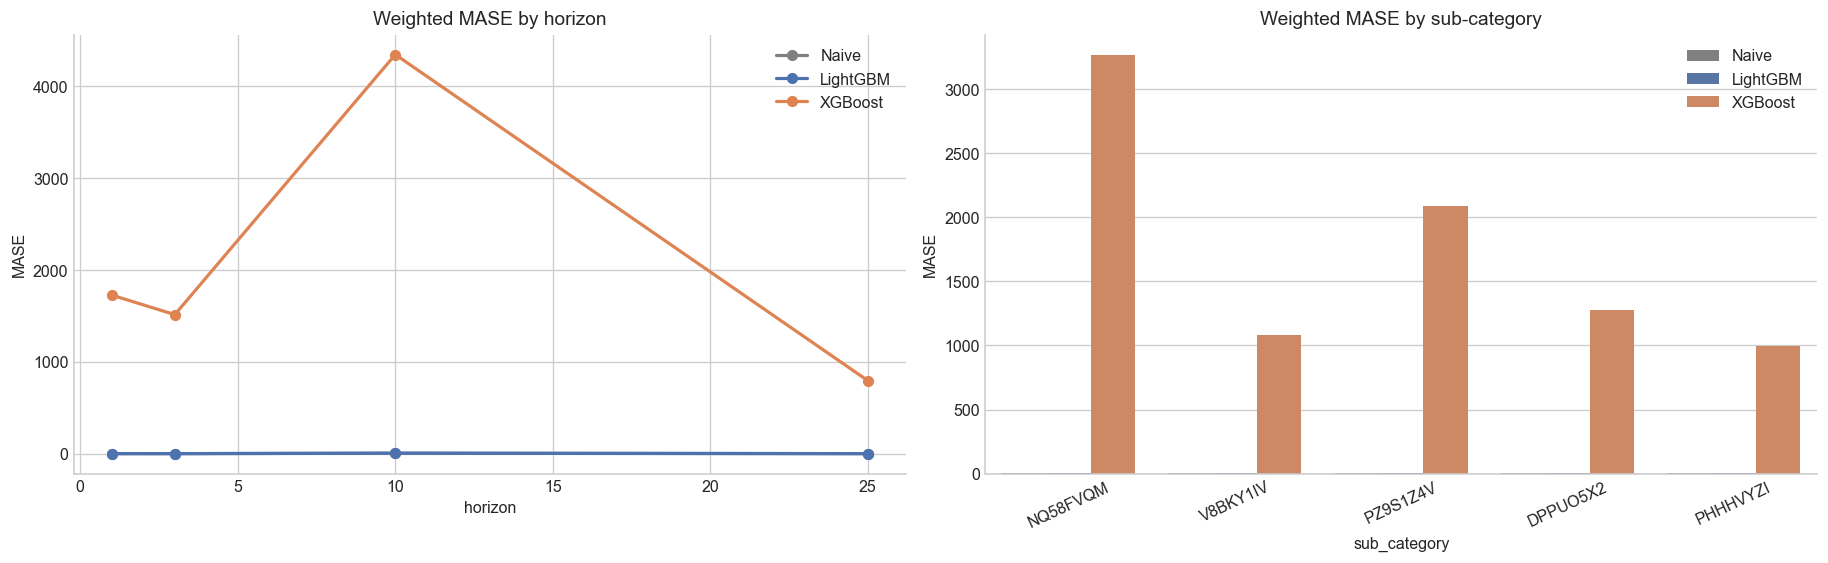

In [7]:
horizon_metrics = grouped_metric_table(val_preds, "horizon", PRED_MAP)
subcat_metrics = grouped_metric_table(val_preds, "sub_category", PRED_MAP).sort_values(
    "total_weight", ascending=False
)

display(horizon_metrics)
display(subcat_metrics[["sub_category", "rows", "total_weight", "naive_mase", "lightgbm_mase", "xgboost_mase"]])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for model in PRED_MAP:
    slug = MODEL_SLUG[model]
    axes[0].plot(
        horizon_metrics["horizon"],
        horizon_metrics[f"{slug}_mase"],
        marker="o",
        linewidth=2,
        label=model,
        color=MODEL_COLOR[model],
    )
axes[0].set_title("Weighted MASE by horizon")
axes[0].set_xlabel("horizon")
axes[0].set_ylabel("MASE")
axes[0].legend()

subcat_plot = subcat_metrics.melt(
    id_vars=["sub_category"],
    value_vars=["naive_mase", "lightgbm_mase", "xgboost_mase"],
    var_name="model",
    value_name="mase",
)
subcat_plot["model"] = subcat_plot["model"].map(
    {
        "naive_mase": "Naive",
        "lightgbm_mase": "LightGBM",
        "xgboost_mase": "XGBoost",
    }
)
sns.barplot(data=subcat_plot, x="sub_category", y="mase", hue="model", palette=MODEL_COLOR, ax=axes[1])
axes[1].set_title("Weighted MASE by sub-category")
axes[1].set_xlabel("sub_category")
axes[1].set_ylabel("MASE")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(title="")

plt.tight_layout()
plt.show()

## 6. Series-level winner analysis

Group-level averages are helpful, but the panel still contains thousands of individual series. This section checks which model wins **series by series**, using weighted MASE within each validation slice.

,series_key,code,sub_code,sub_category,horizon,rows,total_weight,naive_mase,naive_rmse,lightgbm_mase,lightgbm_rmse,xgboost_mase,xgboost_rmse,winner_mase
0,10BAVIDU__83FRDKQ1__DPPUO5X2__1,10BAVIDU,83FRDKQ1,DPPUO5X2,1,71,96.964851,0.490607,2.718096,0.302037,1.749067,0.354087,1.897464,LightGBM
1,10BAVIDU__83FRDKQ1__DPPUO5X2__3,10BAVIDU,83FRDKQ1,DPPUO5X2,3,71,78.559379,0.467399,2.517790,0.386470,2.048862,0.539306,2.675078,LightGBM
2,10BAVIDU__83FRDKQ1__DPPUO5X2__10,10BAVIDU,83FRDKQ1,DPPUO5X2,10,71,85.819240,0.473108,2.483518,0.458870,2.350516,0.649404,3.044608,LightGBM
3,10BAVIDU__83FRDKQ1__DPPUO5X2__25,10BAVIDU,83FRDKQ1,DPPUO5X2,25,71,135.127916,0.664082,2.533760,0.743645,2.631454,0.994606,3.541942,Naive
4,10BAVIDU__83FRDKQ1__NQ58FVQM__1,10BAVIDU,83FRDKQ1,NQ58FVQM,1,71,140.677015,0.913891,2.669722,0.530489,1.740301,0.719721,2.092455,LightGBM


,model,series_wins
0,LightGBM,1086
1,Naive,663
2,XGBoost,78


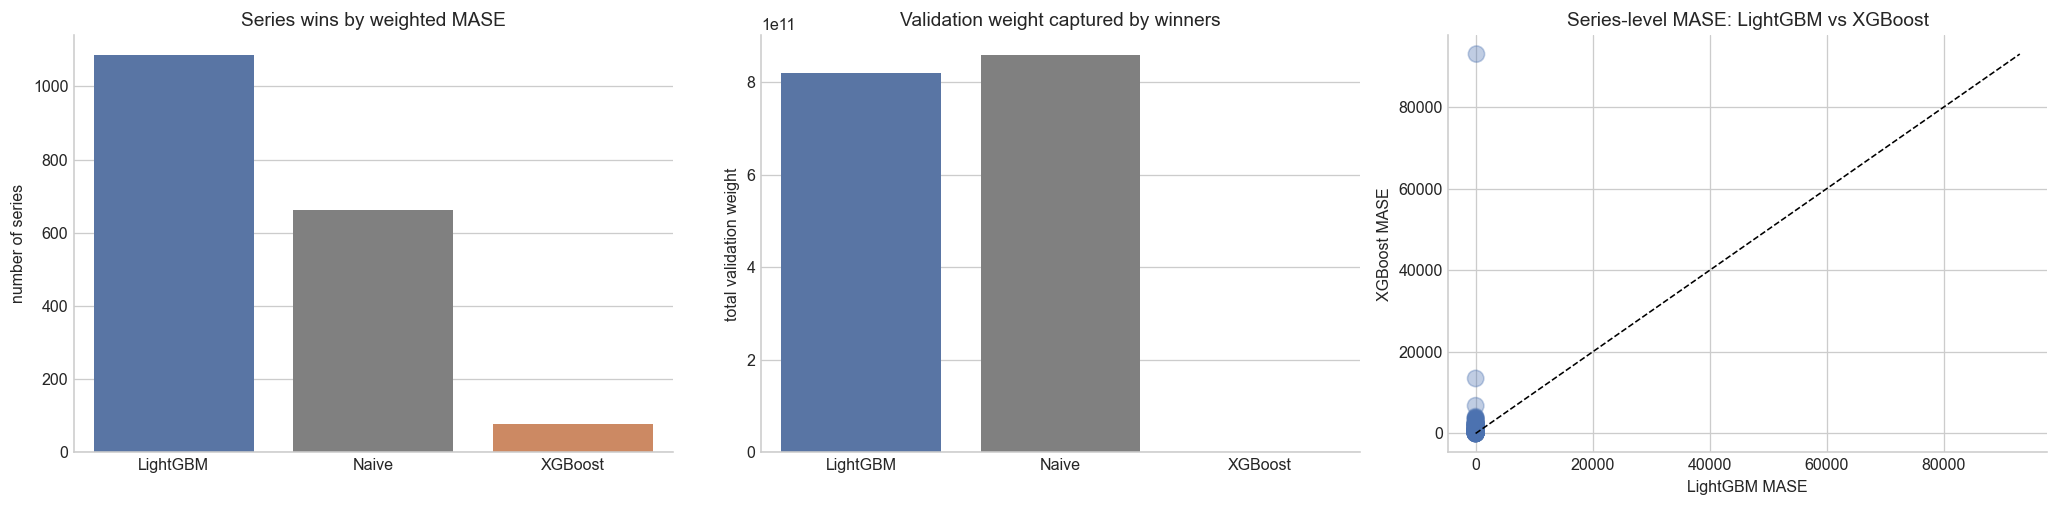

In [8]:
series_rows = []
for key, grp in val_preds.groupby("series_key", sort=False):
    row = {
        "series_key": key,
        "code": grp["code"].iloc[0],
        "sub_code": grp["sub_code"].iloc[0],
        "sub_category": grp["sub_category"].iloc[0],
        "horizon": grp["horizon"].iloc[0],
        "rows": int(len(grp)),
        "total_weight": float(grp["weight"].sum()),
    }
    mase_candidates = {}
    for model, pred_col in PRED_MAP.items():
        slug = MODEL_SLUG[model]
        row[f"{slug}_mase"] = weighted_mase(
            grp["y_true"], grp[pred_col], grp["weight"], grp["mase_scale"]
        )
        row[f"{slug}_rmse"] = weighted_rmse(grp["y_true"], grp[pred_col], grp["weight"])
        mase_candidates[model] = row[f"{slug}_mase"]
    valid_candidates = {k: v for k, v in mase_candidates.items() if pd.notna(v)}
    row["winner_mase"] = min(valid_candidates, key=valid_candidates.get) if valid_candidates else np.nan
    series_rows.append(row)

series_metrics = pd.DataFrame(series_rows)
winner_counts = (
    series_metrics["winner_mase"].value_counts().rename_axis("model").reset_index(name="series_wins")
)
winner_weight = (
    series_metrics.groupby("winner_mase", as_index=False)["total_weight"].sum()
    .rename(columns={"winner_mase": "model", "total_weight": "validation_weight_won"})
)

display(series_metrics.head())
display(winner_counts)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

sns.barplot(data=winner_counts, x="model", y="series_wins", palette=MODEL_COLOR, ax=axes[0])
axes[0].set_title("Series wins by weighted MASE")
axes[0].set_xlabel("")
axes[0].set_ylabel("number of series")

sns.barplot(
    data=winner_weight,
    x="model",
    y="validation_weight_won",
    palette=MODEL_COLOR,
    ax=axes[1],
)
axes[1].set_title("Validation weight captured by winners")
axes[1].set_xlabel("")
axes[1].set_ylabel("total validation weight")

scatter_df = series_metrics.dropna(subset=["lightgbm_mase", "xgboost_mase"]).copy()
size_scale = np.log1p(scatter_df["total_weight"])
size_scale = 20 + 90 * size_scale / size_scale.max()
axes[2].scatter(
    scatter_df["lightgbm_mase"],
    scatter_df["xgboost_mase"],
    s=size_scale,
    alpha=0.35,
    color="#4C72B0",
)
lim_max = np.nanmax(
    [
        scatter_df["lightgbm_mase"].max(),
        scatter_df["xgboost_mase"].max(),
    ]
)
axes[2].plot([0, lim_max], [0, lim_max], color="black", linestyle="--", linewidth=1)
axes[2].set_title("Series-level MASE: LightGBM vs XGBoost")
axes[2].set_xlabel("LightGBM MASE")
axes[2].set_ylabel("XGBoost MASE")

plt.tight_layout()
plt.show()

## 7. Error diagnostics

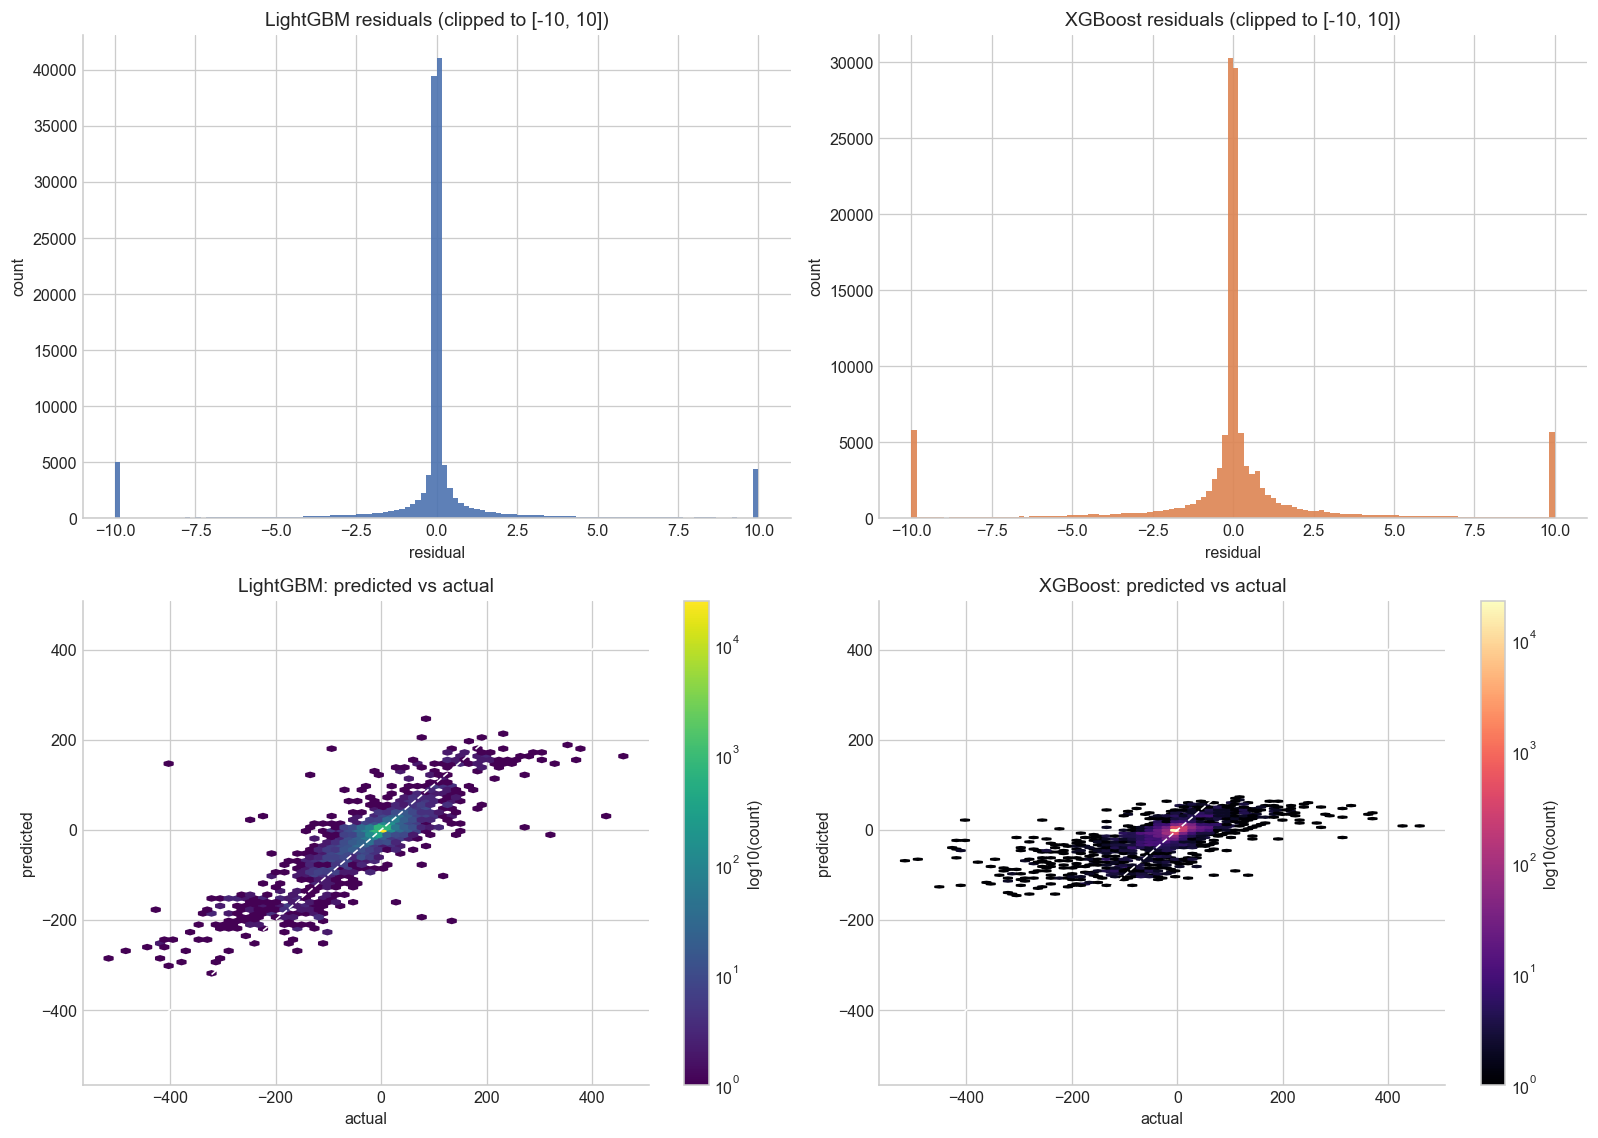

In [9]:
val_preds["naive_resid"] = val_preds["y_true"] - val_preds["naive_pred"]
val_preds["lgb_resid"] = val_preds["y_true"] - val_preds["lgb_pred"]
val_preds["xgb_resid"] = val_preds["y_true"] - val_preds["xgb_pred"]

sample = val_preds.sample(min(len(val_preds), 30000), random_state=SEED)
sample_min = float(np.nanmin([sample["y_true"].min(), sample["lgb_pred"].min(), sample["xgb_pred"].min()]))
sample_max = float(np.nanmax([sample["y_true"].max(), sample["lgb_pred"].max(), sample["xgb_pred"].max()]))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(np.clip(val_preds["lgb_resid"], -10, 10), bins=120, color="#4C72B0", alpha=0.9)
axes[0, 0].set_title("LightGBM residuals (clipped to [-10, 10])")
axes[0, 0].set_xlabel("residual")
axes[0, 0].set_ylabel("count")

axes[0, 1].hist(np.clip(val_preds["xgb_resid"], -10, 10), bins=120, color="#DD8452", alpha=0.9)
axes[0, 1].set_title("XGBoost residuals (clipped to [-10, 10])")
axes[0, 1].set_xlabel("residual")
axes[0, 1].set_ylabel("count")

hb1 = axes[1, 0].hexbin(
    sample["y_true"],
    sample["lgb_pred"],
    gridsize=60,
    bins="log",
    cmap="viridis",
)
axes[1, 0].plot([sample_min, sample_max], [sample_min, sample_max], "w--", linewidth=1)
axes[1, 0].set_title("LightGBM: predicted vs actual")
axes[1, 0].set_xlabel("actual")
axes[1, 0].set_ylabel("predicted")
fig.colorbar(hb1, ax=axes[1, 0], label="log10(count)")

hb2 = axes[1, 1].hexbin(
    sample["y_true"],
    sample["xgb_pred"],
    gridsize=60,
    bins="log",
    cmap="magma",
)
axes[1, 1].plot([sample_min, sample_max], [sample_min, sample_max], "w--", linewidth=1)
axes[1, 1].set_title("XGBoost: predicted vs actual")
axes[1, 1].set_xlabel("actual")
axes[1, 1].set_ylabel("predicted")
fig.colorbar(hb2, ax=axes[1, 1], label="log10(count)")

plt.tight_layout()
plt.show()

## 8. Feature importance and interpretation

Native tree importances are useful for fast inspection. To make them readable, we show both:

- top individual features
- aggregated importance by feature family

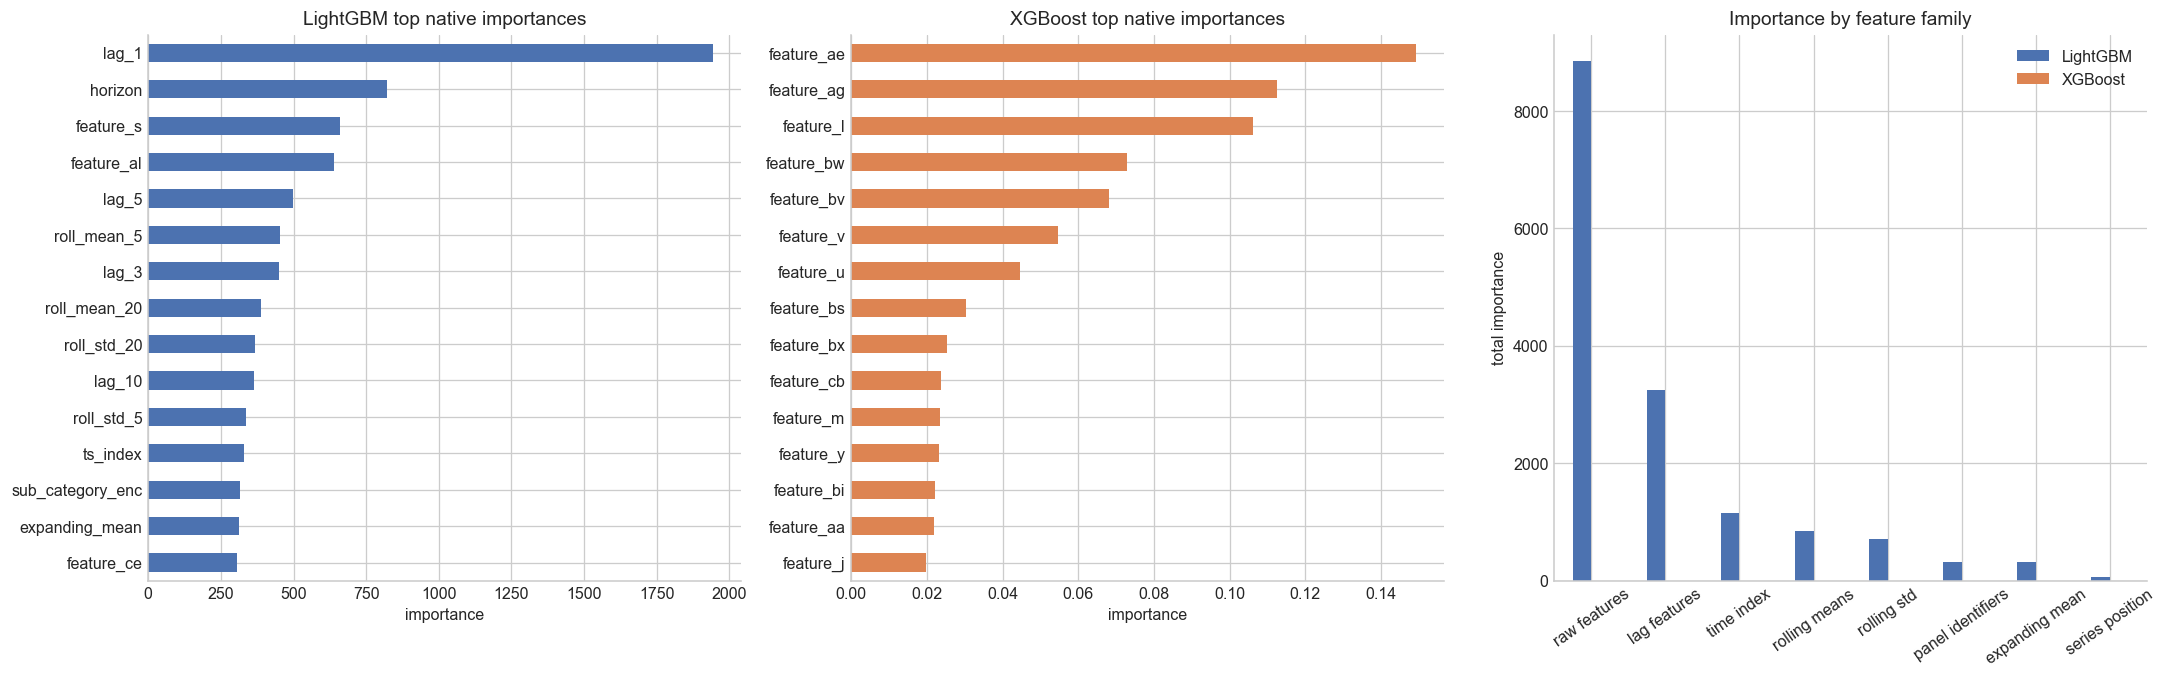

,LightGBM,XGBoost
feature_group,,
raw features,8860,0.951633
lag features,3257,0.006491
time index,1151,0.000773
rolling means,840,0.003866
rolling std,704,0.024293
panel identifiers,320,0.001017
expanding mean,311,0.004499
series position,57,0.007429


In [10]:
lgb_importance = pd.Series(lgb_model.feature_importances_, index=model_features).sort_values(ascending=False)
xgb_importance = pd.Series(xgb_model.feature_importances_, index=model_features).sort_values(ascending=False)

group_importance = pd.DataFrame(
    {
        "feature": model_features,
        "LightGBM": lgb_model.feature_importances_,
        "XGBoost": xgb_model.feature_importances_,
    }
)
group_importance["feature_group"] = group_importance["feature"].map(feature_group_name)
group_importance = (
    group_importance.groupby("feature_group")[["LightGBM", "XGBoost"]]
    .sum()
    .assign(total=lambda df: df["LightGBM"] + df["XGBoost"])
    .sort_values("total", ascending=False)
    .drop(columns="total")
)

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

lgb_importance.head(15).sort_values().plot.barh(color="#4C72B0", ax=axes[0])
axes[0].set_title("LightGBM top native importances")
axes[0].set_xlabel("importance")
axes[0].set_ylabel("")

xgb_importance.head(15).sort_values().plot.barh(color="#DD8452", ax=axes[1])
axes[1].set_title("XGBoost top native importances")
axes[1].set_xlabel("importance")
axes[1].set_ylabel("")

group_importance.plot.bar(ax=axes[2], color=["#4C72B0", "#DD8452"])
axes[2].set_title("Importance by feature family")
axes[2].set_xlabel("")
axes[2].set_ylabel("total importance")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

display(group_importance)

## 9. SHAP view for LightGBM

SHAP is slower than native importance, so we run it on a sample of validation rows. The goal is not exhaustive attribution; it is a quick sense of which features move predictions the most.

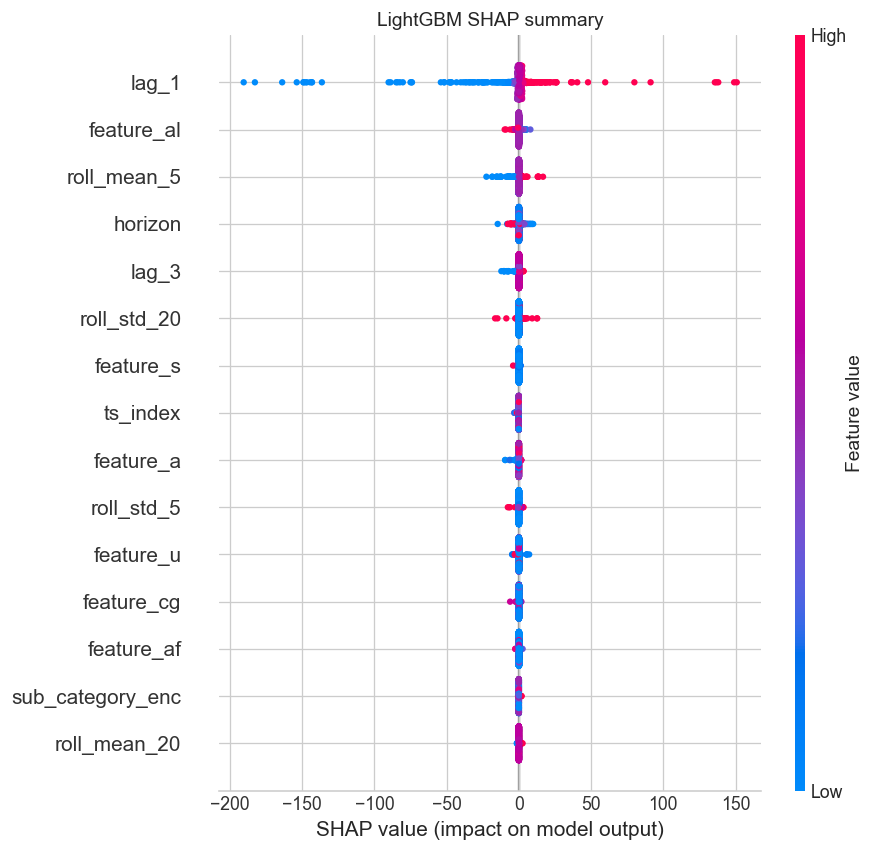

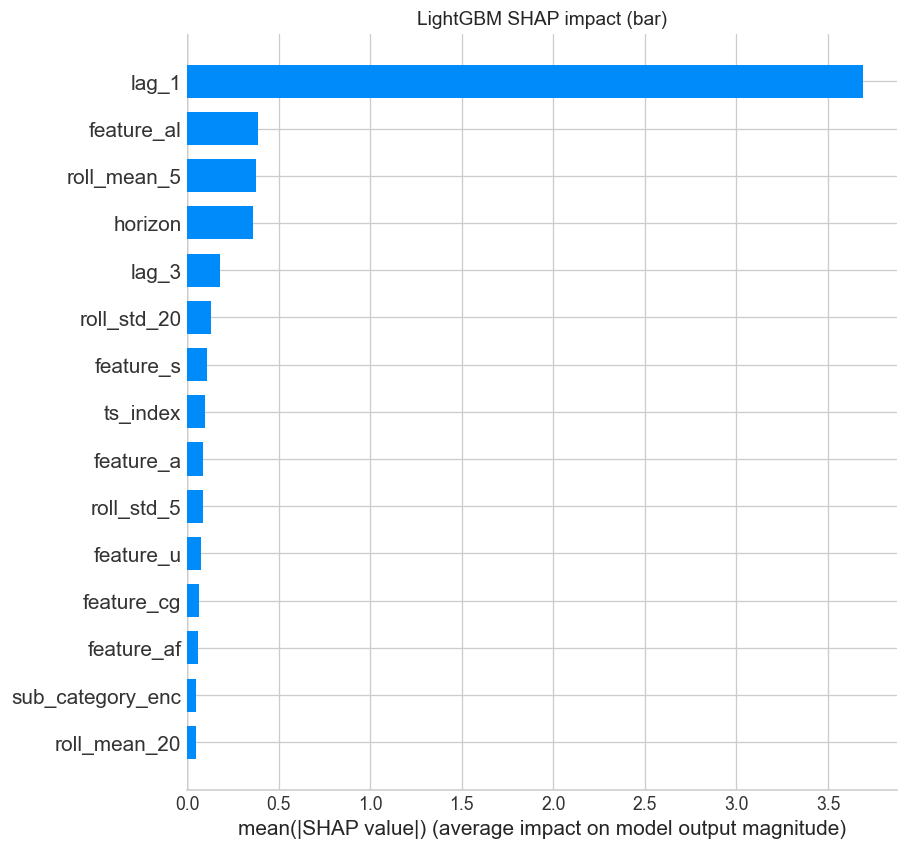

In [11]:
shap_sample = val_ml[model_features].sample(min(len(val_ml), 2000), random_state=SEED)
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(shap_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, show=False, max_display=15)
plt.title("LightGBM SHAP summary")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, shap_sample, plot_type="bar", show=False, max_display=15)
plt.title("LightGBM SHAP impact (bar)")
plt.tight_layout()
plt.show()

## 10. Representative-series case studies

We end on the same four EDA-selected series used in `02_classical_codex.ipynb`. This gives a direct visual comparison between:

- a simple one-step persistence baseline
- the global ML models

,reason,code,sub_code,sub_category,horizon,rows,validation_weight,naive_mase,lightgbm_mase,xgboost_mase,winner_mase
0,Longest History,X9BZ68VQ,OYJGNSQK,DPPUO5X2,1,153,6.938801e+02,2.308220,1.631489,1.716708,LightGBM
1,Highest Total Weight,SJZP0OVU,OYJGNSQK,NQ58FVQM,25,136,4.015389e+10,1.182436,1.387376,1462.967945,Naive
2,Most Volatile,W4S29LF4,KL66VIS3,PHHHVYZI,25,31,1.221038e-01,0.915088,1.297625,2.260519,Naive
3,Most Stable,SJZP0OVU,OYJGNSQK,NQ58FVQM,1,148,3.538562e+10,0.563983,0.686353,1197.164888,Naive


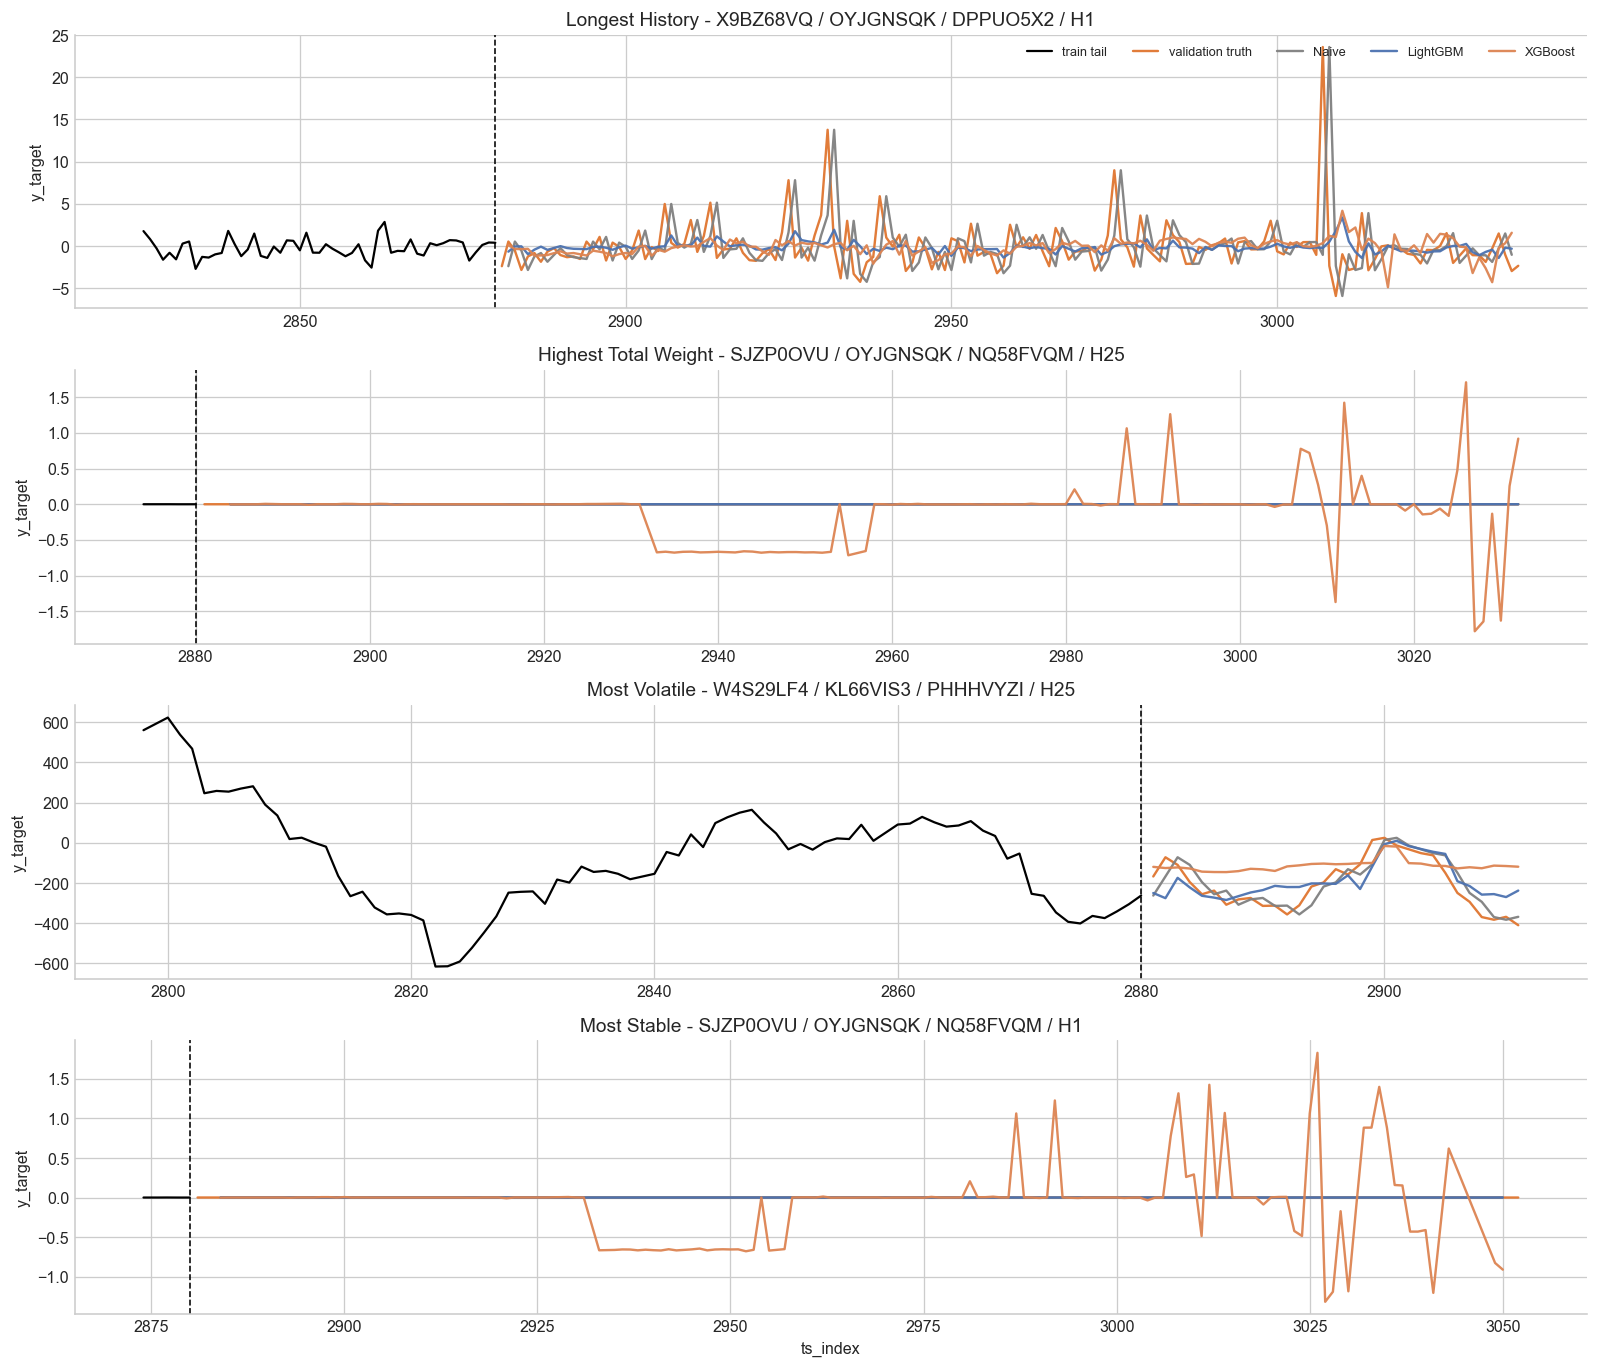

In [12]:
chosen_case_metrics = (
    chosen.merge(series_metrics, on=series_keys, how="left", suffixes=("_panel", "_val"))
    .rename(columns={"total_weight_val": "validation_weight"})
    [
        [
            "reason",
            "code",
            "sub_code",
            "sub_category",
            "horizon",
            "rows",
            "validation_weight",
            "naive_mase",
            "lightgbm_mase",
            "xgboost_mase",
            "winner_mase",
        ]
    ]
)
display(chosen_case_metrics)

fig, axes = plt.subplots(len(chosen), 1, figsize=(14, 12), sharex=False)
axes = np.atleast_1d(axes)

for ax, row in zip(axes, chosen.to_dict("records")):
    hist = get_series_frame(row)
    hist_train = hist[hist["ts_index"] <= VAL_CUTOFF].tail(CASE_TAIL)
    hist_val = hist[hist["ts_index"] > VAL_CUTOFF]
    pred_slice = val_preds[
        np.logical_and.reduce(
            [
                val_preds["code"] == row["code"],
                val_preds["sub_code"] == row["sub_code"],
                val_preds["sub_category"] == row["sub_category"],
                val_preds["horizon"] == row["horizon"],
            ]
        )
    ].sort_values("ts_index")

    ax.plot(hist_train["ts_index"], hist_train["y_target"], color="black", linewidth=1.4, label="train tail")
    ax.plot(hist_val["ts_index"], hist_val["y_target"], color="#E17C3A", linewidth=1.5, label="validation truth")
    ax.plot(pred_slice["ts_index"], pred_slice["naive_pred"], color=MODEL_COLOR["Naive"], alpha=0.95, label="Naive")
    ax.plot(pred_slice["ts_index"], pred_slice["lgb_pred"], color=MODEL_COLOR["LightGBM"], alpha=0.95, label="LightGBM")
    ax.plot(pred_slice["ts_index"], pred_slice["xgb_pred"], color=MODEL_COLOR["XGBoost"], alpha=0.95, label="XGBoost")
    ax.axvline(VAL_CUTOFF, color="black", linestyle="--", linewidth=1)
    ax.set_title(
        f"{row['reason']} - {row['code']} / {row['sub_code']} / {row['sub_category']} / H{row['horizon']}"
    )
    ax.set_ylabel("y_target")

axes[0].legend(loc="upper right", ncol=5, fontsize=8)
axes[-1].set_xlabel("ts_index")
plt.tight_layout()
plt.show()

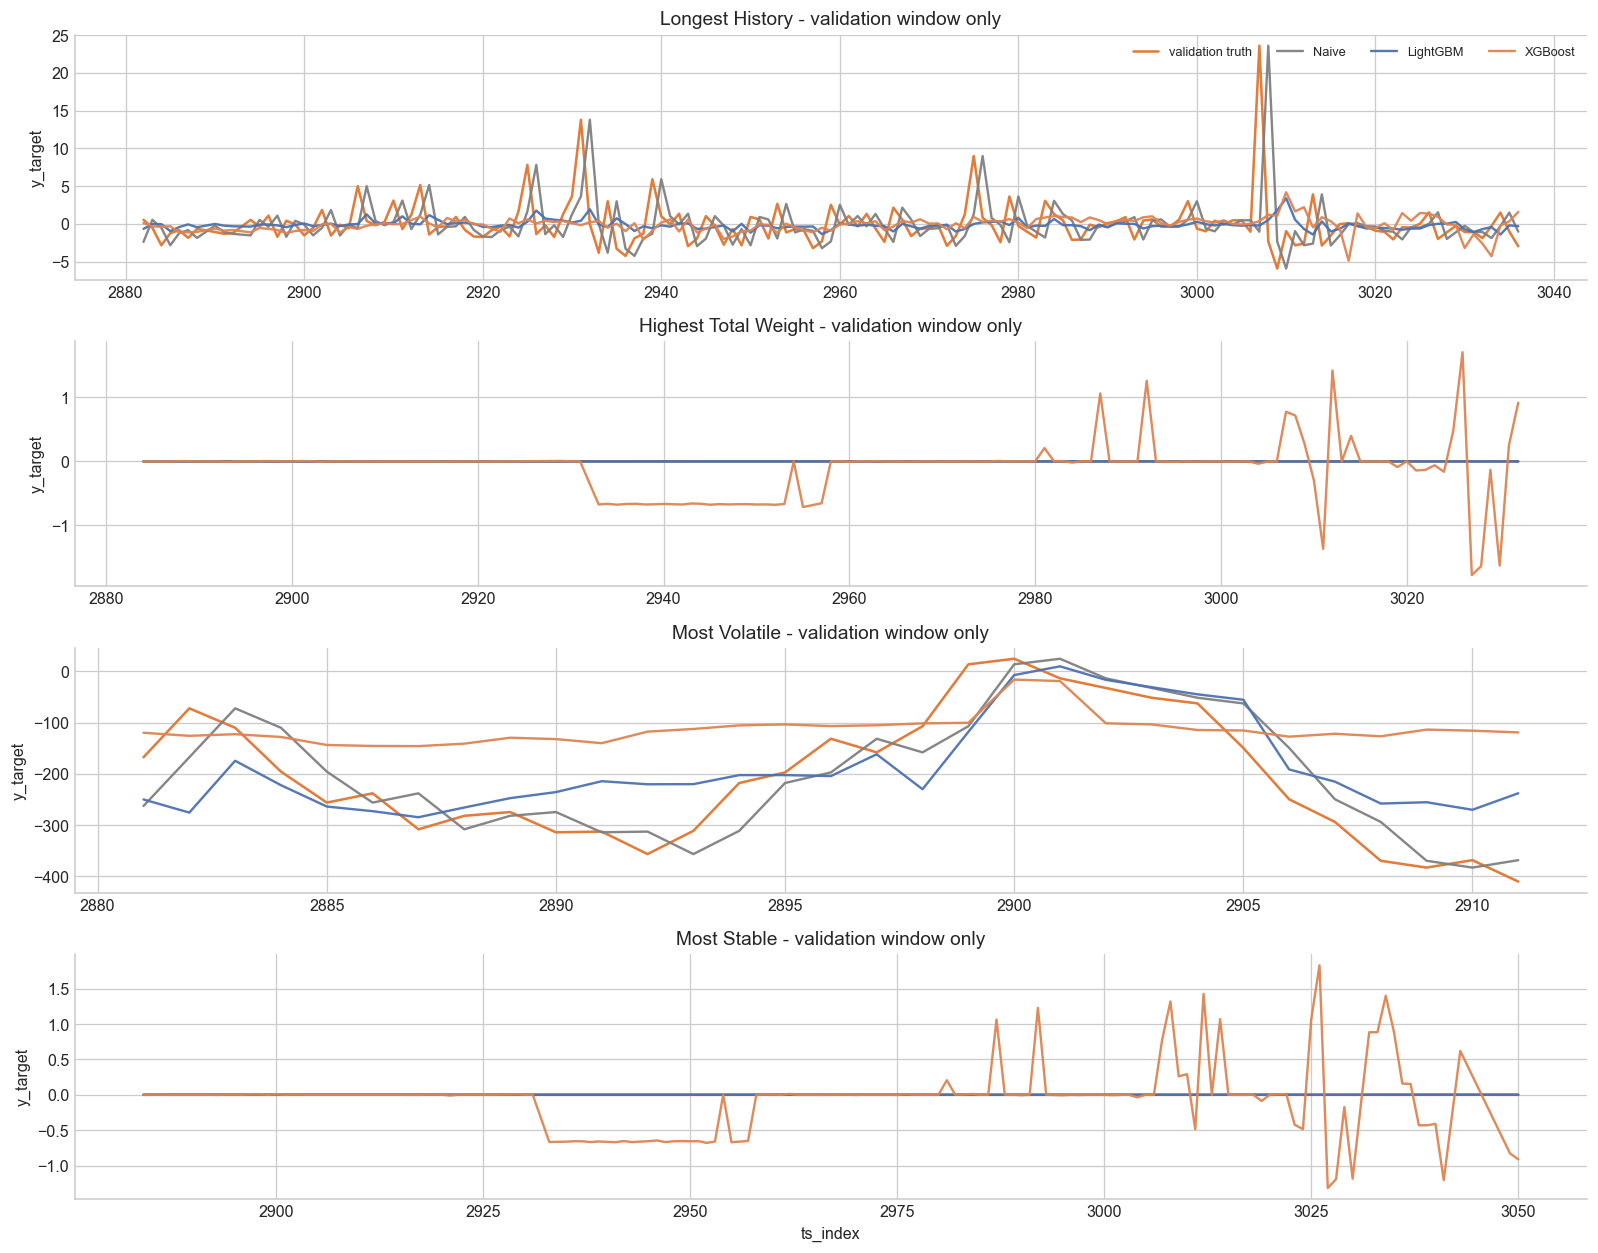

In [13]:
fig, axes = plt.subplots(len(chosen), 1, figsize=(14, 11), sharex=False)
axes = np.atleast_1d(axes)

for ax, row in zip(axes, chosen.to_dict("records")):
    pred_slice = val_preds[
        np.logical_and.reduce(
            [
                val_preds["code"] == row["code"],
                val_preds["sub_code"] == row["sub_code"],
                val_preds["sub_category"] == row["sub_category"],
                val_preds["horizon"] == row["horizon"],
            ]
        )
    ].sort_values("ts_index")
    ax.plot(pred_slice["ts_index"], pred_slice["y_true"], color="#E17C3A", linewidth=1.6, label="validation truth")
    ax.plot(pred_slice["ts_index"], pred_slice["naive_pred"], color=MODEL_COLOR["Naive"], alpha=0.95, label="Naive")
    ax.plot(pred_slice["ts_index"], pred_slice["lgb_pred"], color=MODEL_COLOR["LightGBM"], alpha=0.95, label="LightGBM")
    ax.plot(pred_slice["ts_index"], pred_slice["xgb_pred"], color=MODEL_COLOR["XGBoost"], alpha=0.95, label="XGBoost")
    ax.set_title(f"{row['reason']} - validation window only")
    ax.set_ylabel("y_target")

axes[0].legend(loc="upper right", ncol=4, fontsize=8)
axes[-1].set_xlabel("ts_index")
plt.tight_layout()
plt.show()

## 11. Save artifacts and final takeaways

In [14]:
ml_val_artifact = val_preds[
    [
        "id",
        "y_true",
        "weight",
        "naive_pred",
        "lgb_pred",
        "xgb_pred",
        "code",
        "sub_code",
        "sub_category",
        "horizon",
        "ts_index",
    ]
].copy()
ml_val_artifact.to_parquet(PROCESSED_DIR / "ml_val_preds.parquet", index=False)
overall_metrics.to_parquet(PROCESSED_DIR / "ml_results_summary.parquet", index=False)
series_metrics.to_parquet(PROCESSED_DIR / "ml_series_metrics.parquet", index=False)

best_model = overall_metrics.sort_values(["mase", "rmse"]).iloc[0]
lgb_horizon_wins = int(
    (horizon_metrics["lightgbm_mase"] < horizon_metrics["naive_mase"]).sum()
)
xgb_horizon_wins = int(
    (horizon_metrics["xgboost_mase"] < horizon_metrics["naive_mase"]).sum()
)

print("Saved artifacts:")
print(f"  - {PROCESSED_DIR / 'ml_val_preds.parquet'}")
print(f"  - {PROCESSED_DIR / 'ml_results_summary.parquet'}")
print(f"  - {PROCESSED_DIR / 'ml_series_metrics.parquet'}")
print()
print("Takeaways")
print(f"- Best overall model by weighted MASE: {best_model['model']} ({best_model['mase']:.4f}).")
print(
    f"- Horizon wins versus Naive by MASE: LightGBM {lgb_horizon_wins}/"
    f"{len(horizon_metrics)}, XGBoost {xgb_horizon_wins}/{len(horizon_metrics)}."
)
print(
    f"- Series-level winners: "
    + ", ".join(
        f"{row.model}={row.series_wins}"
        for row in winner_counts.sort_values('series_wins', ascending=False).itertuples(index=False)
    )
    + "."
)
print(
    "- Chosen-series winners: "
    + ", ".join(
        f"{row.reason} -> {row.winner_mase}" for row in chosen_case_metrics.itertuples(index=False)
    )
    + "."
)

Saved artifacts:
  - /Users/jeetraj/Desktop/Everything/DAIICT/Sem_6/Applied_Forecasting_Methods/Project/data/processed/ml_val_preds.parquet
  - /Users/jeetraj/Desktop/Everything/DAIICT/Sem_6/Applied_Forecasting_Methods/Project/data/processed/ml_results_summary.parquet
  - /Users/jeetraj/Desktop/Everything/DAIICT/Sem_6/Applied_Forecasting_Methods/Project/data/processed/ml_series_metrics.parquet

Takeaways
- Best overall model by weighted MASE: Naive (2.4305).
- Horizon wins versus Naive by MASE: LightGBM 1/4, XGBoost 0/4.
- Series-level winners: LightGBM=1086, Naive=663, XGBoost=78.
- Chosen-series winners: Longest History -> LightGBM, Highest Total Weight -> Naive, Most Volatile -> Naive, Most Stable -> Naive.
